## DIABETES PREDECTION

## Import section

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV



from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore')


## Cleaning and Preprocessing

In [3]:
df = pd.read_csv('diabetes_dataset.csv')
df.head()

,Unnamed: 0,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,0,58,Female,White,35.8,83.4,123.9,10.9,152,114,...,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,...,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,...,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0
3,3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,...,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0
4,4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,...,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0


In [4]:
df.describe()

,Unnamed: 0,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Dietary_Intake_Calories,Family_History_of_Diabetes,Previous_Gestational_Diabetes
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,44.620400,29.418150,94.79707,134.776210,9.507510,134.163700,89.558700,225.165540,55.019340,134.35377,55.16822,5.503430,2742.481900,0.507000,0.516500
std,2886.89568,14.343489,6.170866,14.38329,37.633544,3.176421,26.110317,17.237792,42.963744,14.537371,37.50238,25.88180,1.455091,716.643803,0.499976,0.499753
min,0.00000,20.000000,18.500000,70.00000,70.000000,4.000000,90.000000,60.000000,150.000000,30.000000,70.00000,10.00000,3.000000,1500.000000,0.000000,0.000000
25%,2499.75000,32.000000,24.100000,82.20000,102.175000,6.800000,112.000000,75.000000,187.875000,42.300000,101.67500,32.60000,4.200000,2129.000000,0.000000,0.000000
50%,4999.50000,45.000000,29.500000,94.90000,134.500000,9.500000,134.000000,89.000000,225.500000,55.200000,134.40000,55.45000,5.500000,2727.000000,1.000000,1.000000
75%,7499.25000,57.000000,34.700000,107.00000,167.800000,12.300000,157.000000,105.000000,262.400000,67.900000,166.40000,77.50000,6.800000,3368.000000,1.000000,1.000000
max,9999.00000,69.000000,40.000000,120.00000,200.000000,15.000000,179.000000,119.000000,300.000000,80.000000,200.00000,100.00000,8.000000,3999.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     10000 non-null  int64  
 1   Age                            10000 non-null  int64  
 2   Sex                            10000 non-null  object 
 3   Ethnicity                      10000 non-null  object 
 4   BMI                            10000 non-null  float64
 5   Waist_Circumference            10000 non-null  float64
 6   Fasting_Blood_Glucose          10000 non-null  float64
 7   HbA1c                          10000 non-null  float64
 8   Blood_Pressure_Systolic        10000 non-null  int64  
 9   Blood_Pressure_Diastolic       10000 non-null  int64  
 10  Cholesterol_Total              10000 non-null  float64
 11  Cholesterol_HDL                10000 non-null  float64
 12  Cholesterol_LDL                10000 non-null  

In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Ethnicity,0
BMI,0
Waist_Circumference,0
Fasting_Blood_Glucose,0
HbA1c,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0


In [7]:
df.shape

(10000, 21)

In [8]:
df.dropna(inplace=True)
df.shape

(6680, 21)

In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Ethnicity,0
BMI,0
Waist_Circumference,0
Fasting_Blood_Glucose,0
HbA1c,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0


In [10]:
df.drop('Unnamed: 0', axis=1, inplace=True)

AS DATA SET DOESNOT HAVE ANY TARGET COLUMN SO CREATING ONE USING IDEAL VALUES OF MEDICAL REPORTS

In [11]:
def calculate_risk(row):
    score = 0

    # Blood sugar indicators
    if row['Fasting_Blood_Glucose'] > 126:
        score += 2
    if row['HbA1c'] > 6.5:
        score += 2

    # Obesity indicators
    if row['BMI'] > 30:
        score += 1
    if (row['Sex'] == 'Male' and row['Waist_Circumference'] > 102) or (row['Sex'] == 'Female' and row['Waist_Circumference'] > 88):
        score += 1

    # Cholesterol indicators
    if row['Cholesterol_LDL'] > 130:
        score += 1

    # Family history
    if row['Family_History_of_Diabetes'] == 1:
        score += 1

    # Previous Gestational Diabetes
    if row['Previous_Gestational_Diabetes'] == 1:
        score += 1

    # Lifestyle factors
    if row['Physical_Activity_Level'] == 'Low':
        score += 1
    if row['Smoking_Status'] == 'Current':
        score += 1
    if row['Alcohol_Consumption'] == 'Heavy':
        score += 1

    return score

df['Risk_Score'] = df.apply(calculate_risk, axis=1)

In [12]:
df['Risk_Score'].value_counts()

,count
Risk_Score,
6,1346
7,1312
8,1038
5,999
4,681
9,587
3,296
10,230
2,102


CLASSIFYING RISK SCORE VALUE INTO 3 CLASS low : 0 MODERATE : 1 HIGH : 3

In [13]:
def map_risk(score):
    if score <= 4:
        return 0
    elif score <= 7:
        return 1
    else:
        return 2

df['Diabetes_Risk'] = df['Risk_Score'].apply(map_risk)

In [14]:
df['Diabetes_Risk'].value_counts()

,count
Diabetes_Risk,
1,3657
2,1904
0,1119


In [ ]:
df.to_csv('Finall_diabetes_dataset.csv', index=False)

## Model Training

USING THE PREPROCESSED DATASET

In [16]:
df = pd.read_csv('Finall_diabetes_dataset.csv')
df.shape

(6680, 22)

In [17]:
df.isna().sum()

,0
Age,0
Sex,0
Ethnicity,0
BMI,0
Waist_Circumference,0
Fasting_Blood_Glucose,0
HbA1c,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Total,0


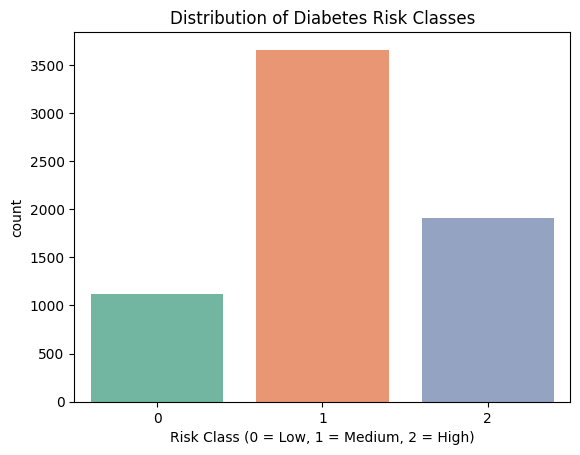

In [18]:
sns.countplot(x='Diabetes_Risk', data=df, palette='Set2')
plt.title('Distribution of Diabetes Risk Classes')
plt.xlabel('Risk Class (0 = Low, 1 = Medium, 2 = High)')
plt.show()

In [19]:
categorical_cols = ['Sex', 'Ethnicity', 'Physical_Activity_Level', 'Alcohol_Consumption', 'Smoking_Status']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df.drop(columns=['Diabetes_Risk','Risk_Score'], axis=1)
y = df['Diabetes_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [21]:
smote = SMOTE(sampling_strategy='auto',random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [22]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_smote, y_train_smote)
y_pred = rf_model.predict(X_test)
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test,y_pred))

Accuracy on Test Data: 0.8288423153692615
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       336
           1       0.83      0.86      0.85      1097
           2       0.85      0.83      0.84       571

    accuracy                           0.83      2004
   macro avg       0.82      0.81      0.81      2004
weighted avg       0.83      0.83      0.83      2004



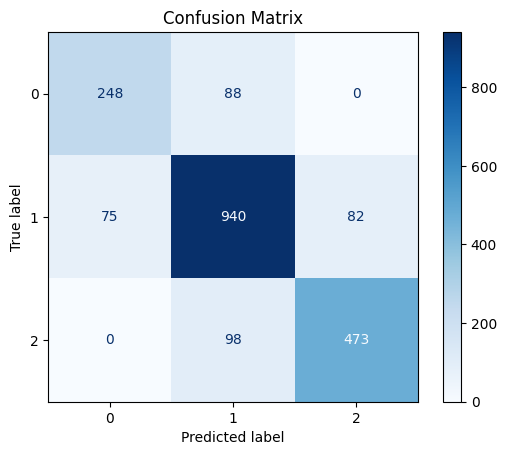

In [23]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

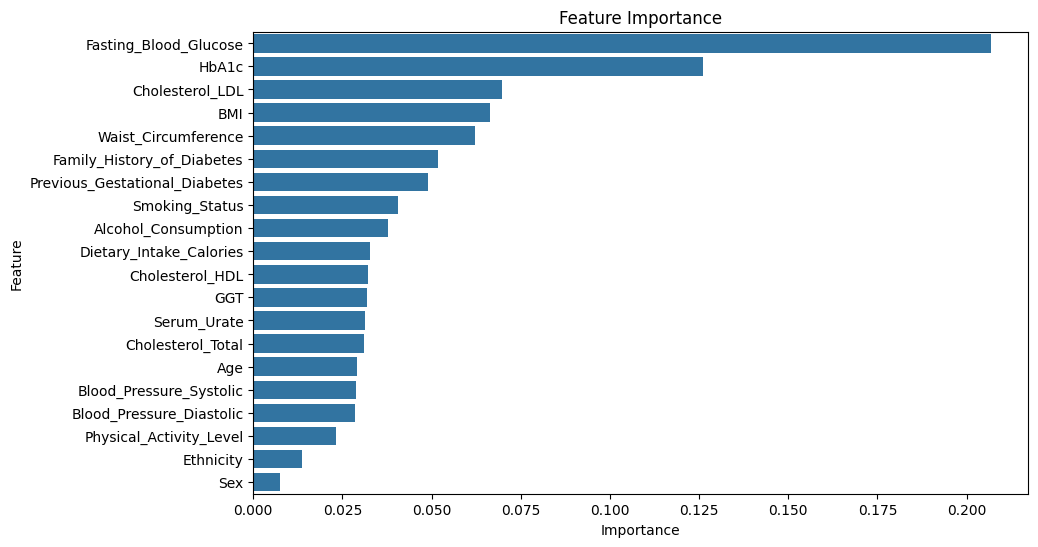

In [24]:
importances = rf_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({"Feature": features, "Importance": importances})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()


In [25]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Test Data: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy on Test Data: 0.8677644710578842

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       336
           1       0.88      0.88      0.88      1097
           2       0.90      0.87      0.88       571

    accuracy                           0.87      2004
   macro avg       0.86      0.86      0.86      2004
weighted avg       0.87      0.87      0.87      2004



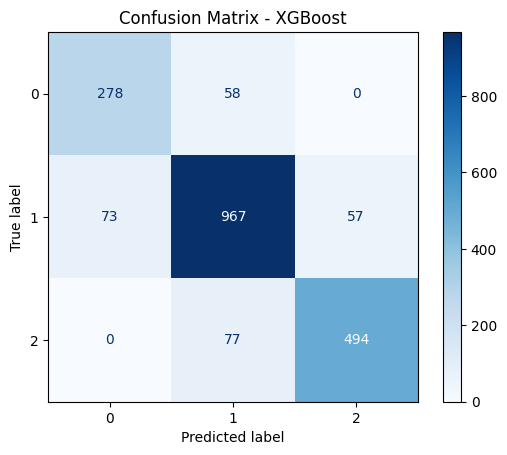

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

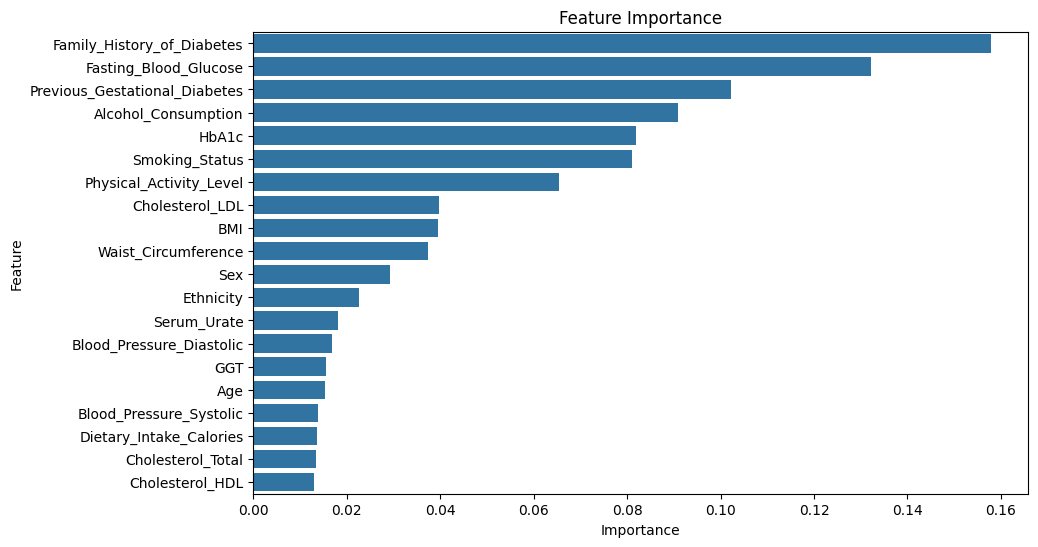

In [27]:
importances = xgb_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({"Feature": features, "Importance": importances})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()


## HYPER TUNNING MODELS

XBGC Model

In [28]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=20, cv=5, n_jobs=-1, random_state=42)
random_search_xgb.fit(X_train, y_train)

print("Best parameters from RandomizedSearchCV:", random_search_xgb.best_params_)


Best parameters from RandomizedSearchCV: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [250, 300, 350],
    'learning_rate': [0.08, 0.1, 0.12],
    'max_depth': [4, 5, 6],
    'min_child_weight': [4, 5, 6],
    'subsample': [0.75, 0.8, 0.85],
}

grid_search = GridSearchCV(xgb_model, param_grid=param_grid, scoring = 'f1_macro',cv=5, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters from GridSearchCV:", grid_search.best_params_)


Best parameters from GridSearchCV: {'learning_rate': 0.12, 'max_depth': 5, 'min_child_weight': 6, 'n_estimators': 350, 'subsample': 0.85}


Accuracy on Test Data tunned xgbc : 0.8927145708582834
Classification Report tunned xgbc :
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       336
           1       0.91      0.90      0.90      1097
           2       0.92      0.92      0.92       571

    accuracy                           0.89      2004
   macro avg       0.88      0.88      0.88      2004
weighted avg       0.89      0.89      0.89      2004



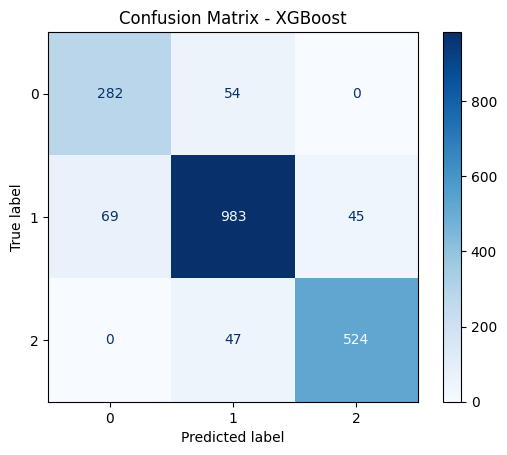

In [30]:
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Accuracy on Test Data tunned xgbc :", accuracy_score(y_test, y_pred))
print("Classification Report tunned xgbc :")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

RandomForest Model

In [35]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],

}

random_search_rf = RandomizedSearchCV(rf_model, param_distributions=param_dist_rf,
                                      n_iter=10, cv=5, n_jobs=-1, random_state=42)
random_search_rf.fit(X_train_smote, y_train_smote)

print("Best parameters from RandomizedSearchCV:", random_search_rf.best_params_)


Best parameters from RandomizedSearchCV: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 25, 'criterion': 'entropy', 'bootstrap': False}


In [38]:
param_grid_rf = {
    'n_estimators': [500],
    'max_depth': [25],
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'max_features': ['log2'],
    'bootstrap': [False],
    'criterion': ['entropy']
}


grid_search_rf = GridSearchCV(rf_model, param_grid=param_grid_rf, scoring='f1_macro', cv=5, n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_smote, y_train_smote)

print("Best parameters from GridSearchCV:", grid_search_rf.best_params_)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters from GridSearchCV: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}


Accuracy on Test Data Tunned Rf : 0.8458083832335329
Classification Report Tuned Rf :
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       336
           1       0.85      0.87      0.86      1097
           2       0.87      0.85      0.86       571

    accuracy                           0.85      2004
   macro avg       0.84      0.83      0.83      2004
weighted avg       0.85      0.85      0.85      2004



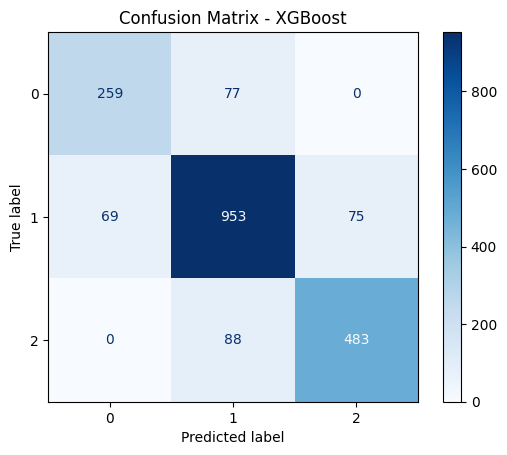

In [39]:
best_rf = grid_search_rf.best_estimator_
y_pred = best_rf.predict(X_test)
print("Accuracy on Test Data Tunned Rf :", accuracy_score(y_test, y_pred))
print("Classification Report Tuned Rf :")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

STACKING MODELS

Accuracy on Test Data (Stacked Model): 0.8942115768463074

Classification Report (Stacked Model):
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       336
           1       0.91      0.90      0.90      1097
           2       0.91      0.92      0.92       571

    accuracy                           0.89      2004
   macro avg       0.88      0.89      0.88      2004
weighted avg       0.89      0.89      0.89      2004



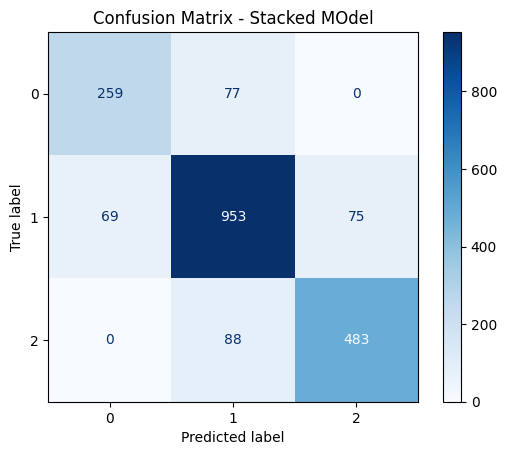

In [40]:
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1,
    passthrough=False
)


stacking_model.fit(X_train_smote, y_train_smote)
y_pred_stack = stacking_model.predict(X_test)
print("Accuracy on Test Data (Stacked Model):", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report (Stacked Model):\n", classification_report(y_test, y_pred_stack))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix - Stacked MOdel")
plt.show()

In [41]:
import joblib

joblib.dump(stacking_model, 'stacking_model.pkl')
print("Stacking Model Saved Successfully!")

Stacking Model Saved Successfully!
